In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import requests
from io import StringIO

# Plot style
plt.rcParams['figure.dpi']         = 150
plt.rcParams['axes.spines.top']    = False
plt.rcParams['axes.spines.right']  = False
plt.rcParams['axes.grid']          = True
plt.rcParams['grid.alpha']         = 0.3
plt.rcParams['grid.linestyle']     = '--'

## I. Repo GC Rate Proxy via ESTER (Data: ECB API) 

In [2]:
def fetch_ecb_series(dataflow: str, series_key: str,
                     start: str = "2015-01-01") -> pd.Series:
    """Fetch a time series from the ECB Data Portal API."""
    url = (
        f"https://data-api.ecb.europa.eu/service/data/"
        f"{dataflow}/{series_key}?format=csvdata&startPeriod={start}"
    )
    response = requests.get(url, timeout=15)
    response.raise_for_status()
    df = pd.read_csv(StringIO(response.text))
    df = df[["TIME_PERIOD", "OBS_VALUE"]].copy()
    df["TIME_PERIOD"] = pd.to_datetime(df["TIME_PERIOD"])
    df = df.set_index("TIME_PERIOD").sort_index()
    df["OBS_VALUE"] = pd.to_numeric(df["OBS_VALUE"], errors="coerce")
    return df["OBS_VALUE"]


#  ESTER overnight (ECB reference) 
ester = fetch_ecb_series("EST", "B.EU000A2X2A25.WT")

# Repo GC Proxy
# Historical Spread ESTER/GC between -5bps and -15bps
# Sources : ECB, ICMA repo market surveys (March 2026) (https://www.icmagroup.org/assets/documents/Regulatory/Repo/Surveys/ICMA-European-Repo-Market-Survey-number-50-conducted-December-2025-published-March-2026-260326.pdf)
GC_SPREAD_BPS = -10  # Conservative Proxy : GC = ESTER - 10bps
repo_gc = ester + (GC_SPREAD_BPS / 100)

print("ESTER")
print(f"Observations : {len(ester)}")
print(f"Period      : {ester.index[0].date()} → {ester.index[-1].date()}")
print(f"Last      : {ester.iloc[-1]:.4f}%")

print("\nRepo GC Proxy (ESTER - 10bps)")
print(f"Last      : {repo_gc.iloc[-1]:.4f}%")

print("\n ESTER Metrics")
print(f"ESTER mean  : {ester.mean():.3f}%")
print(f"ESTER min    : {ester.min():.3f}% ({ester.idxmin().date()})")
print(f"ESTER max    : {ester.max():.3f}% ({ester.idxmax().date()})")

ESTER
Observations : 1678
Period      : 2019-10-01 → 2026-04-21
Last      : 1.9320%

Repo GC Proxy (ESTER - 10bps)
Last      : 1.8320%

 ESTER Metrics
ESTER mean  : 1.269%
ESTER min    : -0.593% (2022-03-31)
ESTER max    : 3.913% (2024-06-03)


### ESTER & Repo GC Proxy

The €STR (Euro Short-Term Rate / ESTER) is the ECB's overnight reference rate, 
published since October 2019. It replaced EONIA as the standard risk-free 
rate for euro-denominated derivatives and repo transactions.

**Repo GC Proxy construction:**
The euro General Collateral (GC) repo rate typically trades slightly below 
ESTER due to the collateral benefit — secured funding is cheaper than 
unsecured. We apply a conservative **-10bps spread** consistent with 
historical ICMA repo market surveys.

$$r_{GC}(t) = \text{ESTER}(t) - 10\text{bps}$$

**Key rate regimes observed:**
- **2019–2022:** Negative rate environment (ESTER at -0.59%) — funding was 
  free, repo GC deeply negative, carry dynamics inverted
- **2022–2024:** Historic tightening cycle (+450bps in 18 months) — 
  funding costs became a critical P&L driver for leveraged positions
- **2024–present:** Easing cycle, ESTER at 1.93% — positive carry 
  environment returning but funding costs still material

 *In production, GC repo rates are sourced from live broker screens 
(BrokerTec, MTS Repo) or Bloomberg RRRA. Our proxy is a directional 
approximation — the spread vs ESTER can widen significantly during 
stress (year-end, quarter-end) or ECB reserve maintenance periods.*


---
---

## II. SSA BONDS and Bund Benchmarks

In [3]:
# Public Data : Issuers (Bundesrepublik, EIB site), Euronext, Luxembourg Stock Exchange, Deutsche Börse
# We chose the most liquid Euro SSA Bonds : Kfw (Agency), EIB (Supra) and Bund as a benchmark.
bonds = {
    # KfW 5Y benchmark
    "KfW_5Y": {
        "issuer"      : "KfW",
        "isin"        : "XS3344416287",
        "coupon"      : 2.875,      # %
        "maturity"    : "2031-06-30",
        "price"       : 99.985,      # price : https://live.deutsche-boerse.com/bond/xs3344416287-kred-f-wied-26-31-mtn?mic=XFRA
        "rating"      : "AAA",
        "duration"    : 4.224,       # modified duration in years : https://live.deutsche-boerse.com/bond/xs3344416287-kred-f-wied-26-31-mtn?mic=XFRA
        "dv01"        : 422.4,        # EUR per bp per 1M notional
        "repo_spread" : -2,         # bps vs GC (SSA trades near GC)
    },
    # KfW 10Y benchmark
    "KfW_10Y": {
        "issuer"      : "KfW",
        "isin"        : "XS3326554261",
        "coupon"      : 4.68,
        "maturity"    : "2036-03-26",
        "price"       : 100.00, # Not up to date compared to others https://www.luxse.com/security/XS3326554261/506208
        "rating"      : "AAA",
        "duration"    : 8.90, # Approx
        "dv01"        : 890,
        "repo_spread" : -3,
    },
    # EIB 5Y benchmark https://www.eib.org/en/investor-relations/outstanding-issues/index?q=&sortColumn=maturityDate&sortDir=asc&pageNumber=0&itemPerPage=9&pageable=false&la=EN&deLa=EN&orUseProceedsDesc=true&orTypeDesc=true&currency=EUR&orCurrency=true
    "EIB_5Y": {
        "issuer"      : "EIB",
        "isin"        : "EU000A4EPCA0",
        "coupon"      : 2.625,
        "maturity"    : "2031-06-16",
        "price"       : 98.72, # as of 21/04/2026 https://live.deutsche-boerse.com/bond/eu000a4epca0-eib-26-31-mtn?mic=XFRA
        "rating"      : "AAA",
        "duration"    : 4.213,
        "dv01"        : 421.3, #https://live.deutsche-boerse.com/bond/eu000a4epca0-eib-26-31-mtn?mic=XFRA
        "repo_spread" : -3,
    },
    # EIB 10Y benchmark https://www.eib.org/en/investor-relations/outstanding-issues/index?q=&sortColumn=maturityDate&sortDir=asc&pageNumber=0&itemPerPage=9&pageable=false&la=EN&deLa=EN&orUseProceedsDesc=true&orTypeDesc=true&currency=EUR&orCurrency=true
    "EIB_10Y": {
        "issuer"      : "EIB",
        "isin"        : "EU000A4EM8H8",
        "coupon"      : 3.00,
        "maturity"    : "2036-01-14",
        "price"       : 98.20, # as of 21/04/2026 https://live.deutsche-boerse.com/bond/eu000a4em8h8-eib-26-36-mtn?mic=XFRA
        "rating"      : "AAA",
        "duration"    : 6.304,
        "dv01"        : 630.4,
        "repo_spread" : -4,
    },
    # Bobl 5Y (benchmark) https://www.deutsche-finanzagentur.de/en/federal-securities/factsheet/isin/DE000BU25067
    "Bobl_5Y": {
        "issuer"      : "Germany",
        "isin"        : "DE000BU25067",
        "coupon"      : 2.500,
        "maturity"    : "2031-04-16",
        "price"       : 99.161, # as of 21/04/2026 https://live.deutsche-boerse.com/bond/de000bu25067-bundesobl-v-26-31-s-193?mic=XFRA
        "rating"      : "AAA",
        "duration"    : 4.169, #https://live.deutsche-boerse.com/bond/de000bu25067-bundesobl-v-26-31-s-193?mic=XFRA
        "dv01"        : 416.9,
        "repo_spread" : -8,   # Bund trading more special than SSA
    },
    # Bund 10Y (benchmark + CTD proxy) https://www.deutsche-finanzagentur.de/en/federal-securities/factsheet/isin/DE000BU2Z064
    "Bund_10Y": {
        "issuer"      : "Germany",
        "isin"        : "DE000BU2Z064",
        "coupon"      : 2.900,
        "maturity"    : "2036-02-15",
        "price"       : 99.111, # As of 21/04/2026 https://live.deutsche-boerse.com/bond/de000bu2z064-bundanl-v-26-36?mic=XFRA
        "rating"      : "AAA",
        "duration"    : 6.498, #https://live.deutsche-boerse.com/bond/de000bu2z064-bundanl-v-26-36?mic=XFRA
        "dv01"        : 649.8,
        "repo_spread" : -12,  # Bund 10Y often special (high demand to short it, CTD)
    },
}

df_bonds = pd.DataFrame(bonds).T
df_bonds["maturity"]      = pd.to_datetime(df_bonds["maturity"])
df_bonds["coupon"]        = df_bonds["coupon"].astype(float)
df_bonds["price"]         = df_bonds["price"].astype(float)
df_bonds["duration"]      = df_bonds["duration"].astype(float)
df_bonds["dv01"]          = df_bonds["dv01"].astype(float)
df_bonds["repo_spread"]   = df_bonds["repo_spread"].astype(float)

# Repo rate for each bond
last_gc = repo_gc.iloc[-1]
df_bonds["repo_rate"] = last_gc + df_bonds["repo_spread"] / 100

print("SSA Bonds and Bund Benchmark\n")
print(df_bonds[["issuer", "coupon", "maturity", "price",
                "duration", "repo_spread", "repo_rate"]].to_string())

SSA Bonds and Bund Benchmark

           issuer  coupon   maturity    price  duration  repo_spread  repo_rate
KfW_5Y        KfW   2.875 2031-06-30   99.985     4.224         -2.0      1.812
KfW_10Y       KfW   4.680 2036-03-26  100.000     8.900         -3.0      1.802
EIB_5Y        EIB   2.625 2031-06-16   98.720     4.213         -3.0      1.802
EIB_10Y       EIB   3.000 2036-01-14   98.200     6.304         -4.0      1.792
Bobl_5Y   Germany   2.500 2031-04-16   99.161     4.169         -8.0      1.752
Bund_10Y  Germany   2.900 2036-02-15   99.111     6.498        -12.0      1.712


### SSA Universe — KfW & EIB vs Bund

We define 6 representative benchmark bonds across the 5Y and 10Y tenors:

**SSA issuers:**
- **KfW** (Kreditanstalt für Wiederaufbau) — German development bank, 
  explicit federal guarantee, largest SSA issuer in EUR (~80bn/year)
- **EIB** (European Investment Bank) — EU supranational, AAA rated, 
  second largest SSA issuer in EUR

**Bund benchmarks** serve as the risk-free reference for spread calculations.

**Repo dynamics:**
SSA bonds trade **2–4bps special** vs GC — close to GC but not flat, 
reflecting steady demand from money market funds and repo desks. 
Bunds trade **8–12bps special** due to structural scarcity (Bundesbank 
holdings, hedging demand from rates desks) — this repo advantage is a 
key reason why Bund yields are structurally below SSA despite identical ratings.

> This repo differential is the first layer of the relative value analysis:
> a trade that looks cheap on Z-spread may be expensive once funding is accounted for.

---
---

## III. Carry Trade / Roll Down

In [4]:
# Global assumptions
HORIZON_DAYS = 30 # Carry Horizon
ACT360 = 360
ACT365 = 365
NOTIONAL = 10_000_000 # 10M EUR
CURVE_SLOPE_BPS_PER_YEAR = 5.0  # only for simplified roll-down proxy for SSA curve
today = pd.Timestamp("2026-04-21")

Carry Net & Roll-Down — 30d | 10M EUR 

          Coupon accrual (bps)  Funding cost (bps)  Net carry (bps)  Carry €/10M  Roll-down €/10M  Total return €/10M
Bond                                                                                                                 
KfW_5Y                   23.63               15.10             8.53       8532.0           1736.0             10268.0
KfW_10Y                  38.47               15.02            23.45      23449.0           3658.0             27107.0
EIB_5Y                   21.58               14.82             6.75       6751.0           1731.0              8482.0
EIB_10Y                  24.66               14.66             9.99       9993.0           2591.0             12584.0
Bobl_5Y                  20.55               14.48             6.07       6070.0           1713.0              7784.0
Bund_10Y                 23.84               14.14             9.70       9696.0           2670.0             12366.0


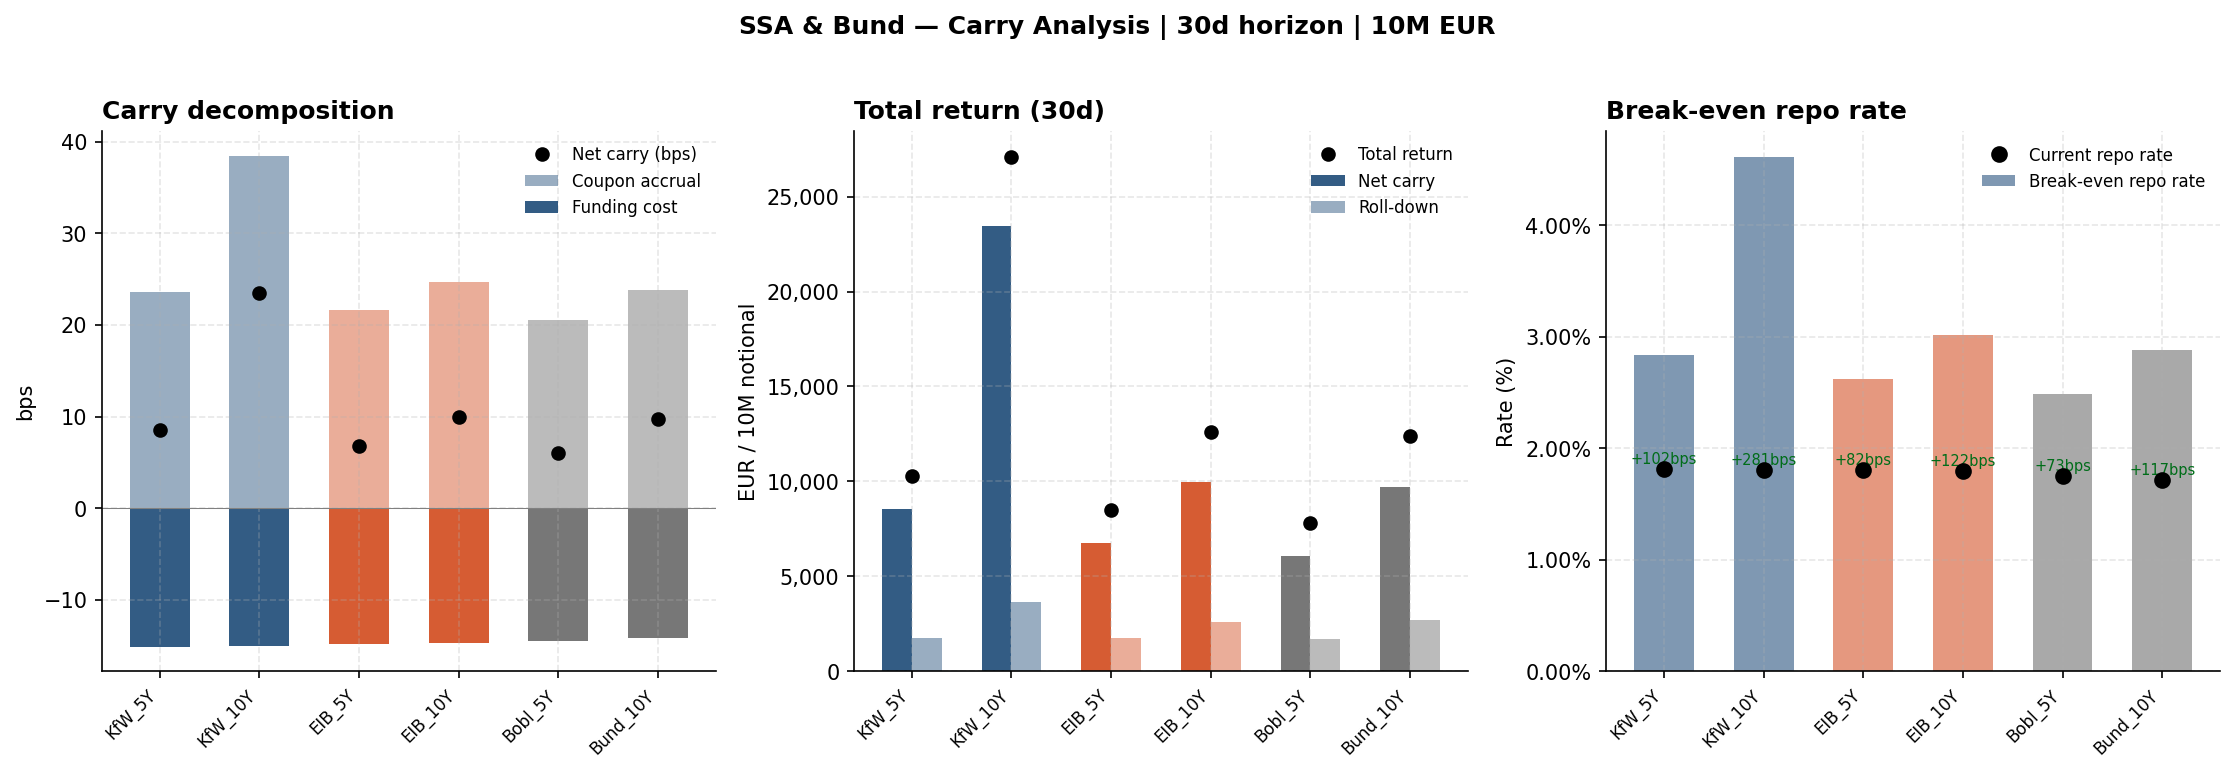

In [5]:
results = []

for bond_name, bond in df_bonds.iterrows():

# Carry Computation

    coupon_accrual = (bond["coupon"] / 100) * (HORIZON_DAYS / ACT365)
    funding_cost   = (bond["price"] / 100) * (bond["repo_rate"] / 100) * \
                     (HORIZON_DAYS / ACT360)
    carry_net      = coupon_accrual - funding_cost
    carry_eur      = carry_net * NOTIONAL
    carry_bps_day  = (carry_net / bond["duration"]) * 10000 / HORIZON_DAYS

# Roll Computation

    roll_down_bps = CURVE_SLOPE_BPS_PER_YEAR * (HORIZON_DAYS / ACT365)
    roll_down_eur = roll_down_bps * bond["dv01"] * (NOTIONAL / 1_000_000)

# Return 

    total_return_eur = carry_eur + roll_down_eur

    results.append({
        "Bond"                : bond_name,
        "Issuer"              : bond["issuer"],
        "Coupon accrual (bps)": round(coupon_accrual * 10000, 2),
        "Funding cost (bps)"  : round(funding_cost   * 10000, 2),
        "Net carry (bps)"     : round(carry_net       * 10000, 2),
        "Carry €/10M"         : round(carry_eur,              0),
        "Roll-down €/10M"     : round(roll_down_eur,          0),
        "Total return €/10M"  : round(total_return_eur,       0),
        "Carry bps/day"       : round(carry_bps_day,          4),
    })

df_carry = pd.DataFrame(results).set_index("Bond")

print(f"Carry Net & Roll-Down — {HORIZON_DAYS}d | {NOTIONAL/1e6:.0f}M EUR \n")
print(df_carry[[
    "Coupon accrual (bps)", "Funding cost (bps)",
    "Net carry (bps)", "Carry €/10M",
    "Roll-down €/10M", "Total return €/10M"
]].to_string())

#  Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5), dpi=150)

bonds_order = ["KfW_5Y", "KfW_10Y", "EIB_5Y", "EIB_10Y", "Bobl_5Y", "Bund_10Y"]
colors = ['#003366','#003366','#CC3300','#CC3300','#555555','#555555']
x = np.arange(len(bonds_order))
width = 0.6

# Panel 1 : Carry Decomposition
ax1 = axes[0]
accrual = df_carry.loc[bonds_order, "Coupon accrual (bps)"]
funding = df_carry.loc[bonds_order, "Funding cost (bps)"]
net     = df_carry.loc[bonds_order, "Net carry (bps)"]

ax1.bar(x, accrual, width, color=colors, alpha=0.4, label='Coupon accrual')
ax1.bar(x, -funding, width, color=colors, alpha=0.8, label='Funding cost')
ax1.plot(x, net, 'ko', markersize=6, label='Net carry (bps)', zorder=5)
ax1.axhline(0, color='gray', linewidth=0.5)
ax1.set_xticks(x)
ax1.set_xticklabels(bonds_order, rotation=45, ha='right', fontsize=8)
ax1.set_ylabel('bps')
ax1.set_title('Carry decomposition', fontweight='bold', loc='left')
ax1.legend(frameon=False, fontsize=8)

# Panel 2 : Total return €
ax2 = axes[1]
carry_eur    = df_carry.loc[bonds_order, "Carry €/10M"]
rolldown_eur = df_carry.loc[bonds_order, "Roll-down €/10M"]
total_eur    = df_carry.loc[bonds_order, "Total return €/10M"]

ax2.bar(x - width/4, carry_eur,    width/2,
        color=colors, alpha=0.8, label='Net carry')
ax2.bar(x + width/4, rolldown_eur, width/2,
        color=colors, alpha=0.4, label='Roll-down')
ax2.plot(x, total_eur, 'ko', markersize=6,
         label='Total return', zorder=5)
ax2.axhline(0, color='gray', linewidth=0.5)
ax2.set_xticks(x)
ax2.set_xticklabels(bonds_order, rotation=45, ha='right', fontsize=8)
ax2.set_ylabel('EUR / 10M notional')
ax2.set_title('Total return (30d)', fontweight='bold', loc='left')
ax2.legend(frameon=False, fontsize=8)
ax2.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda val, _: f'{val:,.0f}'))

# Panel 3 : Break-even repo rate
ax3 = axes[2]
breakeven_repo = []
for bond_name in bonds_order:
    bond = df_bonds.loc[bond_name]
    # carry_net = 0 → coupon_accrual = funding_cost
    # r_repo_be = coupon / price * (360/365)
    r_be = (bond["coupon"] / 100) / (bond["price"] / 100) * (ACT360 / ACT365)
    breakeven_repo.append(r_be * 100)

current_repo = [df_bonds.loc[b, "repo_rate"] for b in bonds_order]

ax3.bar(x, breakeven_repo, width,
        color=colors, alpha=0.5, label='Break-even repo rate')
ax3.plot(x, current_repo, 'ko', markersize=7,
         label='Current repo rate', zorder=5)

# Safety Margin
for i, (be, curr) in enumerate(zip(breakeven_repo, current_repo)):
    margin = be - curr
    ax3.annotate(f'+{margin*100:.0f}bps',
                 xy=(i, curr), xytext=(i, curr + 0.05),
                 ha='center', fontsize=7, color='#006D19')

ax3.set_xticks(x)
ax3.set_xticklabels(bonds_order, rotation=45, ha='right', fontsize=8)
ax3.set_ylabel('Rate (%)')
ax3.set_title('Break-even repo rate', fontweight='bold', loc='left')
ax3.legend(frameon=False, fontsize=8)
ax3.yaxis.set_major_formatter(mtick.PercentFormatter())

plt.suptitle(f'SSA & Bund — Carry Analysis | {HORIZON_DAYS}d horizon | {NOTIONAL/1e6:.0f}M EUR',
             fontweight='bold', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('/Users/martin/Desktop/Quant Finance/Repo/bond-relative-value/notebooks/carry_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### Carry Analysis — Key Insights

#### Net carry decomposition (30d horizon, 10M EUR)

All bonds generate positive net carry in the current rate environment
(ESTER at 1.932%), with **KfW 10Y leading by a wide margin at +23.46 bps**
— driven by its high coupon of 4.68%. This is a structural outlier in the current
easing cycle and should normalize as the bond seasons.

Excluding KfW 10Y, the remaining bonds cluster between +6 and +10 bps
net carry, consistent with a moderately positive carry environment.

**Ranking by net carry:** KfW_10Y > EIB_10Y > Bund_10Y > KfW_5Y > EIB_5Y > Bobl_5Y

#### Roll-down effect

On a positively sloped curve (assumed slope: 5bps/year), roll-down
contributes meaningfully across all bonds — with 10Y bonds benefiting
more than 5Y bonds by construction:

- **10Y bonds:** roll-down contributes €2,591–€3,658/10M/30d
- **5Y bonds:** roll-down contributes €1,713–€1,736/10M/30d

For KfW 10Y, the total return of **€27,107/10M/30d** is dominated by
the carry component (€23,449) — unusually high vs. peers and a direct
reflection of its above-market coupon.

For the remaining bonds, roll-down represents a meaningful share of
total return (20–35%), reinforcing the case for long-duration SSA
positions in a bull-steepening environment.

#### Break-even repo rate — the key risk metric for the repo desk

| Bond | Break-even repo | Current repo | Safety margin |
|---|---|---|---|
| KfW 5Y | 2.87% | 1.83% | **+103 bps** |
| KfW 10Y | 4.62% | 1.80% | **+281 bps** |
| EIB 5Y | 2.61% | 1.80% | **+82 bps** |
| EIB 10Y | 3.00% | 1.79% | **+122 bps** |
| Bobl 5Y | 2.49% | 1.75% | **+74 bps** |
| Bund 10Y | 2.89% | 1.71% | **+117 bps** |

All positions carry substantial safety margins : ranging from **+74 bps
(Bobl 5Y)** to **+281 bps (KfW 10Y)**. The KfW 10Y margin is exceptional
and reflects its high coupon relative to current funding costs.

The break-even repo rate is the **maximum funding cost** a position can
absorb before turning cash-flow negative. In the current environment,
all positions are highly resilient to repo rate shocks — but this
changes rapidly if the ECB pauses its easing cycle or if year-end
repo pressure pushes GC rates higher.

> **Desk implication:** KfW 10Y dominates on raw carry and safety margin
> — but its exceptional metrics stem from an above-market coupon rather
> than structural cheapness. For a repo desk focused on **risk-adjusted
> RV**, EIB 10Y (+10.00 bps carry, +122 bps safety margin, €12,584 total
> return) offers the most balanced profile: meaningful carry, solid
> funding resilience, and a coupon more representative of current market
> levels.

---
---

## IV. Z-Spread and ASW comparison

### ZC Bund Curve : ECB Data via API

In [6]:
tenors_bund = {
    1 : "B.U2.EUR.4F.G_N_A.SV_C_YM.SR_1Y",
    2 : "B.U2.EUR.4F.G_N_A.SV_C_YM.SR_2Y",
    3 : "B.U2.EUR.4F.G_N_A.SV_C_YM.SR_3Y",
    5 : "B.U2.EUR.4F.G_N_A.SV_C_YM.SR_5Y",
    7 : "B.U2.EUR.4F.G_N_A.SV_C_YM.SR_7Y",
    10: "B.U2.EUR.4F.G_N_A.SV_C_YM.SR_10Y",
    15: "B.U2.EUR.4F.G_N_A.SV_C_YM.SR_15Y",
    20: "B.U2.EUR.4F.G_N_A.SV_C_YM.SR_20Y",
    30: "B.U2.EUR.4F.G_N_A.SV_C_YM.SR_30Y",
}

curve_data = {}
for tenor, key in tenors_bund.items():
    try:
        s = fetch_ecb_series("YC", key, start="2015-01-01")
        curve_data[tenor] = s
        print(f"  ✓ {tenor}Y : {s.iloc[-1]:.3f}%")
    except Exception as e:
        print(f"  ✗ {tenor}Y : {e}")

df_curve = pd.DataFrame(curve_data)
df_curve.columns = [f"{t}Y" for t in df_curve.columns]

# Current Spot Curve

spot_curve = df_curve.iloc[-1]
print(f"\nCourbe Bund spot — {df_curve.index[-1].date()}")
print(spot_curve.to_string())

  ✓ 1Y : 2.383%
  ✓ 2Y : 2.456%
  ✓ 3Y : 2.490%
  ✓ 5Y : 2.619%
  ✓ 7Y : 2.791%
  ✓ 10Y : 3.037%
  ✓ 15Y : 3.324%
  ✓ 20Y : 3.469%
  ✓ 30Y : 3.487%

Courbe Bund spot — 2026-04-21
1Y     2.383125
2Y     2.456008
3Y     2.490282
5Y     2.618729
7Y     2.791249
10Y    3.036528
15Y    3.323924
20Y    3.468832
30Y    3.486754


### Curve Interpolation and Z-Spread computation

In [7]:
from scipy.interpolate import CubicSpline
from scipy.optimize import brentq

# Cubic Interpolation

tenors_num = np.array([1, 2, 3, 5, 7, 10, 15, 20, 30])
yields_num = spot_curve.values / 100 

cs = CubicSpline(tenors_num, yields_num)

def spot_rate(t: float) -> float:
    """Spot Rate Interpolated at a Maturity t."""
    return float(cs(np.clip(t, tenors_num[0], tenors_num[-1])))

def discount_factor(t: float, z_spread: float = 0.0) -> float:
    """Discount Factor with additive z-spread."""
    r = spot_rate(t) + z_spread
    return np.exp(-r * t)

def bond_price_theoretical(coupon: float,
                            maturity_years: float,
                            freq: int = 1,
                            z_spread: float = 0.0) -> float:
    """
    Theoretical Price of the fixed coupon Bond
    coupon    : annual (ex: 0.025)
    freq      : frequency (1 = annual coupon)
    z_spread  : additive spread on the whole curve
    """
    dt      = 1 / freq
    n_flows = int(maturity_years * freq)
    price   = 0.0

    for i in range(1, n_flows + 1):
        t_i = i * dt
        cf  = coupon / freq
        if i == n_flows:
            cf += 1.0   # Notionnal Reimbursement
        price += cf * discount_factor(t_i, z_spread)

    return price * 100  #  % of par

def compute_z_spread(coupon: float,
                     maturity_years: float,
                     market_price: float,
                     freq: int = 1) -> float:
    """
    Compute Z-spread using Dichotomy
    Look for z such as theoretical price (z) = Market Price
    """
    def objective(z):
        return bond_price_theoretical(coupon, maturity_years,
                                      freq, z) - market_price

    # Search in [-200bps, +500bps]
    try:
        z = brentq(objective, -0.02, 0.05, xtol=1e-8)
        return z * 10000  # in bps
    except ValueError:
        return np.nan

# Z-Spread computation for each bond
today = pd.Timestamp("2026-04-21")
z_results = []

for bond_name, bond in df_bonds.iterrows():
    mat_years = (bond["maturity"] - today).days / 365.25
    coupon    = bond["coupon"] / 100
    price     = bond["price"]

    z_spread = compute_z_spread(coupon, mat_years, price)

    price_theoretical = bond_price_theoretical(coupon, mat_years)

    # Richness/cheapness (in price)
    richness_price = price - price_theoretical

    # Richness/cheapness (in rates bps via duration)
    richness_bps = -richness_price / (bond["duration"] / 100)

    z_results.append({
        "Bond"              : bond_name,
        "Issuer"            : bond["issuer"],
        "Maturity (Y)"      : round(mat_years, 2),
        "Market price"      : price,
        "Theoretical price" : round(price_theoretical, 4),
        "Richness (price)"  : round(richness_price, 4),
        "Richness (bps)"    : round(richness_bps, 2),
        "Z-spread (bps)"    : round(z_spread, 2),
    })

df_zspreads = pd.DataFrame(z_results).set_index("Bond")

print("Z-Spreads vs Bund Curve \n")
print(df_zspreads[[
    "Issuer", "Maturity (Y)", "Market price",
    "Theoretical price", "Richness (bps)", "Z-spread (bps)"
]].to_string())

print("\nInterpretations")
print("Z-spread > 0 → bond trading CHEAP vs Bund (spread premium SSA)")
print("Z-spread < 0 → bond trading RICH vs Bund (rare, except Bund on itself)")
print("Richness > 0 → bond trading RICH in price (above theoretical curve)")
print("Richness < 0 → bond trading CHEAP in price (below)")

Z-Spreads vs Bund Curve 

           Issuer  Maturity (Y)  Market price  Theoretical price  Richness (bps)  Z-spread (bps)
Bond                                                                                            
KfW_5Y        KfW          5.19        99.985           101.0589           25.42           22.59
KfW_10Y       KfW          9.93       100.000           113.4491          151.11          166.36
EIB_5Y        EIB          5.15        98.720            99.8996           28.00           25.01
EIB_10Y       EIB          9.73        98.200           100.2269           32.15           25.52
Bobl_5Y   Germany          4.99        99.161            99.7243           13.51           14.69
Bund_10Y  Germany          9.82        99.111            99.4399            5.06            4.12

Interpretations
Z-spread > 0 → bond trading CHEAP vs Bund (spread premium SSA)
Z-spread < 0 → bond trading RICH vs Bund (rare, except Bund on itself)
Richness > 0 → bond trading RICH in price (abov

### ASW computation via Swap Proxy

In [8]:
# Historical Level : swap spread 10Y EUR ≈ -20bps to -40bps compared to Bund curve
# Source : ECB, BIS Quarterly Review 2015-2023

SWAP_GOVT_SPREAD = -25 / 10000  # -25bps : conservative proxy

swap_yields = yields_num + SWAP_GOVT_SPREAD
cs_swap = CubicSpline(tenors_num, swap_yields)

def swap_rate(t: float) -> float:
    """EUR Swap Rate (Bund - 25bps)."""
    return float(cs_swap(
        np.clip(t, tenors_num[0], tenors_num[-1])))

def par_swap_rate(maturity_years: float, freq: int = 1) -> float:
    dt      = 1 / freq
    n       = int(maturity_years * freq)
    annuity = sum(
        np.exp(-swap_rate(i * dt) * (i * dt))
        for i in range(1, n + 1)
    )
    df_final = np.exp(-swap_rate(maturity_years) * maturity_years)
    return (1 - df_final) / annuity

def compute_asw(coupon: float,
                maturity_years: float,
                market_price: float,
                freq: int = 1) -> float:
    dt         = 1 / freq
    n          = int(maturity_years * freq)
    annuity    = sum(
        np.exp(-swap_rate(i * dt) * (i * dt)) / freq
        for i in range(1, n + 1)
    )
    par_rate   = par_swap_rate(maturity_years, freq)
    coupon_leg = (coupon - par_rate) * annuity
    price_leg  = (1.0 - market_price / 100)
    return ((coupon_leg + price_leg) / annuity) * 10000

# Computation 
asw_results = []

for bond_name, bond in df_bonds.iterrows():
    mat_years = (bond["maturity"] - today).days / 365.25
    coupon    = bond["coupon"] / 100
    price     = bond["price"]
    z_spread  = df_zspreads.loc[bond_name, "Z-spread (bps)"]
    asw       = compute_asw(coupon, mat_years, price)
    zs_asw    = z_spread - asw

    asw_results.append({
        "Bond"          : bond_name,
        "Issuer"        : bond["issuer"],
        "Maturity (Y)"  : round(mat_years, 2),
        "Z-spread (bps)": round(z_spread, 2),
        "ASW (bps)"     : round(asw, 2),
        "Z-ASW diff"    : round(zs_asw, 2),
    })

df_asw = pd.DataFrame(asw_results).set_index("Bond")

print("ASW (swap spread = -25bps vs Bund)\n")
print(df_asw.to_string())


ASW (swap spread = -25bps vs Bund)

           Issuer  Maturity (Y)  Z-spread (bps)  ASW (bps)  Z-ASW diff
Bond                                                                  
KfW_5Y        KfW          5.19           22.59      38.60      -16.01
KfW_10Y       KfW          9.93          166.36     165.03        1.33
EIB_5Y        EIB          5.15           25.01      42.72      -17.71
EIB_10Y       EIB          9.73           25.52      26.24       -0.72
Bobl_5Y   Germany          4.99           14.69     -22.13       36.82
Bund_10Y  Germany          9.82            4.12       1.86        2.26


### Comparative visualisation 

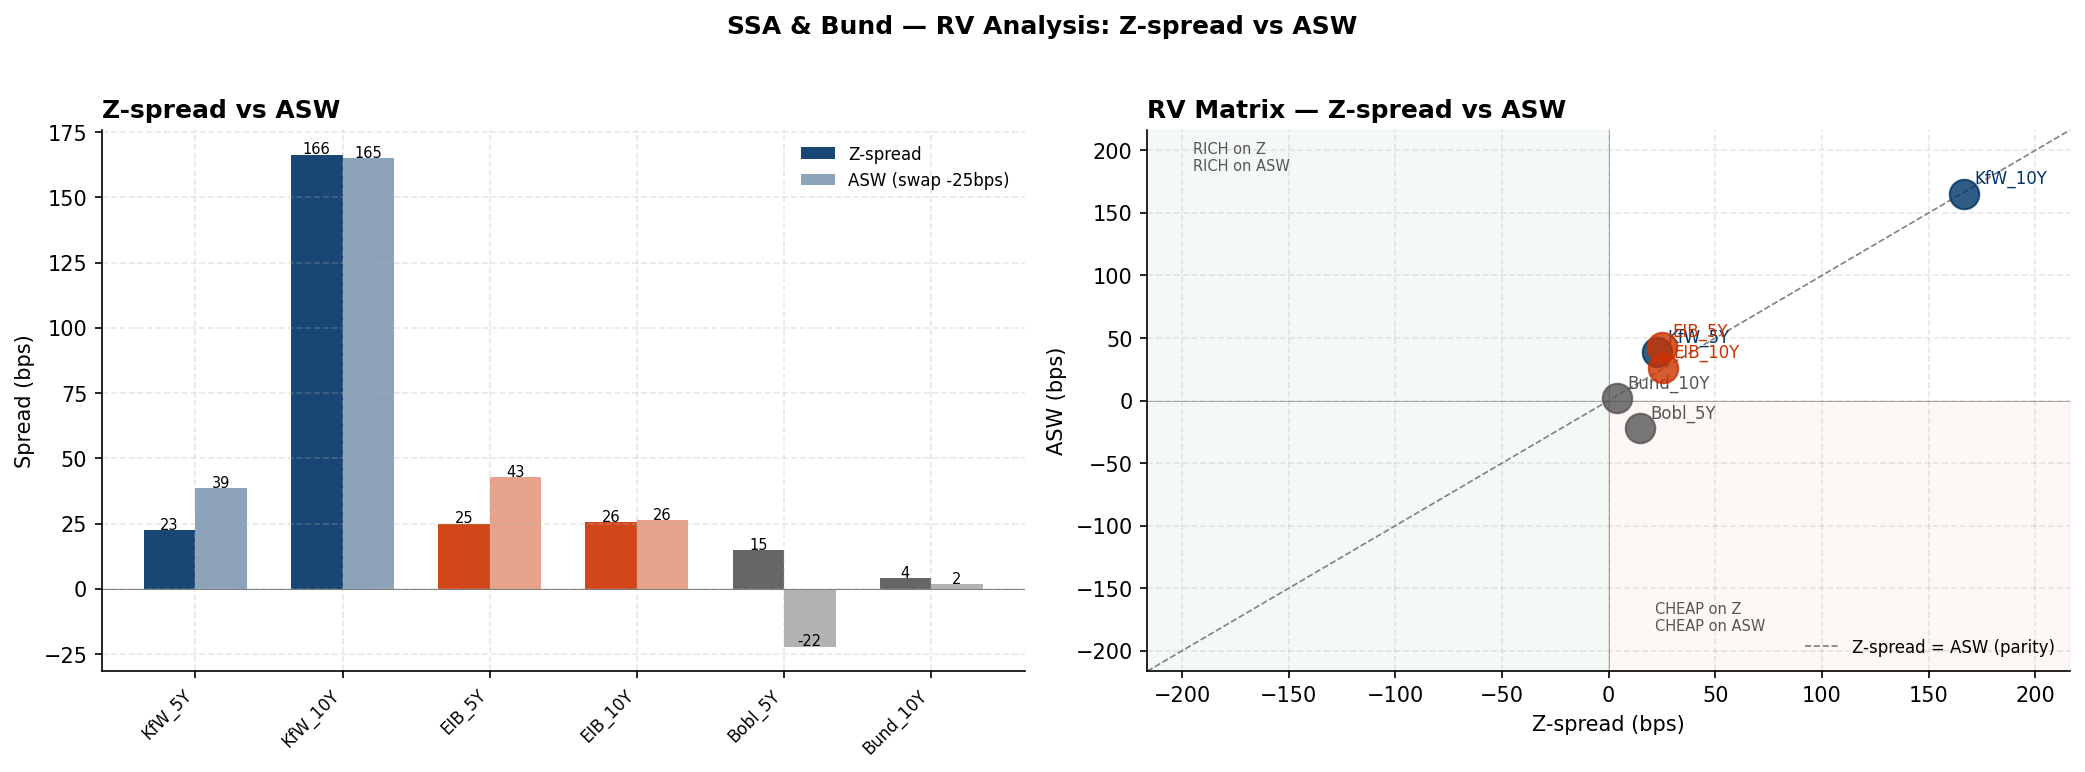

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=150)

bonds_order = ["KfW_5Y", "KfW_10Y", "EIB_5Y",
               "EIB_10Y", "Bobl_5Y", "Bund_10Y"]
colors = ['#003366', '#003366', '#CC3300',
          '#CC3300', '#555555', '#555555']
x     = np.arange(len(bonds_order))
width = 0.35

# Panel 1 : Z-spread vs ASW
ax1 = axes[0]
zs_vals  = df_asw.loc[bonds_order, "Z-spread (bps)"]
asw_vals = df_asw.loc[bonds_order, "ASW (bps)"]

ax1.bar(x - width / 2, zs_vals,  width,
        color=colors, alpha=0.9, label='Z-spread')
ax1.bar(x + width / 2, asw_vals, width,
        color=colors, alpha=0.45, label='ASW (swap -25bps)')
ax1.axhline(0, color='gray', linewidth=0.5)
ax1.set_xticks(x)
ax1.set_xticklabels(bonds_order, rotation=45, ha='right', fontsize=8)
ax1.set_ylabel('Spread (bps)')
ax1.set_title('Z-spread vs ASW',
              fontweight='bold', loc='left')
ax1.legend(frameon=False, fontsize=8)


for i, (z, a) in enumerate(zip(zs_vals, asw_vals)):
    ax1.text(i - width / 2, z + 0.3, f'{z:.0f}',
             ha='center', fontsize=7)
    ax1.text(i + width / 2, a + 0.3, f'{a:.0f}',
             ha='center', fontsize=7)

# Panel 2 : RV matrix : Z-spread vs ASW bubble chart
ax2 = axes[1]
for i, bond_name in enumerate(bonds_order):
    z = df_asw.loc[bond_name, "Z-spread (bps)"]
    a = df_asw.loc[bond_name, "ASW (bps)"]
    c = colors[i]
    ax2.scatter(z, a, s=200, color=c, alpha=0.8, zorder=5)
    ax2.annotate(bond_name, (z, a),
                 xytext=(5, 5), textcoords='offset points',
                 fontsize=8, color=c)

# Parity line Z = ASW
all_z = df_asw["Z-spread (bps)"]
lim   = max(abs(all_z.min()), abs(all_z.max())) * 1.3
ax2.plot([-lim, lim], [-lim, lim],
         color='gray', linewidth=0.8,
         linestyle='--', label='Z-spread = ASW (parity)')
ax2.axhline(0, color='gray', linewidth=0.3)
ax2.axvline(0, color='gray', linewidth=0.3)

# Quadrants
ax2.fill_between([-lim, 0], [-lim, -lim], [lim, lim],
                 alpha=0.04, color='#006D19')
ax2.fill_between([0, lim], [-lim, -lim], [0, 0],
                 alpha=0.04, color='#CC3300')
ax2.text(-lim * 0.9,  lim * 0.85,
         'RICH on Z\nRICH on ASW', fontsize=7,
         color='#555555', ha='left')
ax2.text( lim * 0.1, -lim * 0.85,
         'CHEAP on Z\nCHEAP on ASW', fontsize=7,
         color='#555555', ha='left')
ax2.set_xlabel('Z-spread (bps)')
ax2.set_ylabel('ASW (bps)')
ax2.set_title('RV Matrix — Z-spread vs ASW',
              fontweight='bold', loc='left')
ax2.legend(frameon=False, fontsize=8)
ax2.set_xlim(-lim, lim)
ax2.set_ylim(-lim, lim)

plt.suptitle('SSA & Bund — RV Analysis: Z-spread vs ASW',
             fontweight='bold', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('/Users/martin/Desktop/Quant Finance/Repo/bond-relative-value/notebooks/rv_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

---
---

## V. Methodological Note : Z-spread & ASW Analysis

### The negative swap spread phenomenon in the euro area

Since 2015, EUR swap spreads have been structurally **negative**: EUR swap
rates trade **below** AAA government (Bund) yields.

$$\text{Swap Spread} = r_{swap} - r_{Bund} < 0$$

This phenomenon, well-documented by the BIS and ECB, is driven by three factors:

- **ECB QE-induced Bund scarcity:** massive central bank purchases compressed
  Bund yields below the "pure" risk-free rate
- **Post-Basel III balance sheet constraints:** reduced dealer capacity to
  intermediate swaps pushed swap rates structurally lower relative to govts
- **Safe-haven premium on Bunds:** persistent flight-to-quality demand
  compresses Bund yields independently of swap dynamics

In practice (2024–2026), the EUR 10Y swap spread trades around **-20 to -35 bps**.

### Impact on ASW computation

The Asset Swap Spread is highly sensitive to the absolute level of the
swap curve used as reference. Without access to live EUR swap rates
(Bloomberg `EUSA` ticker), our proxy introduces a **systematic bias of
15 to 20 bps** across most computed ASW levels — rendering absolute ASW
levels unreliable, though **relative comparisons across bonds remain
directionally informative**.

**In production at a repo desk :**
- ASW are computed from live `EUSA` rates sourced directly from Bloomberg
- The desk uses ASW to monitor the relative funding cost of a bond position
  vs its repo financing
- A negative ASW on an SSA bond signals that the bond is funded
  **below Euribor** — a strong indicator of technical demand

### Z-spread results — what the data shows

The Z-spread vs the ECB Bund curve is the most robust metric here,
relying solely on ECB-published data without any swap proxy. It measures
the **credit and liquidity premium** of SSA bonds over pure government:

| Bond | Z-spread (bps) | Richness (bps) | Interpretation |
|---|---|---|---|
| KfW 10Y | +166 | +151 | Exceptional coupon premium (4.68%) — structurally cheap vs curve |
| EIB 5Y | +25 | +28 | Standard SSA premium — consistent with peer KfW 5Y |
| EIB 10Y | +26 | +32 | Marginally tighter than EIB 5Y — moderate 10Y compression |
| KfW 5Y | +23 | +25 | Standard SSA premium on the 5Y point |
| Bobl 5Y | +15 | +14 | Government bond — modest premium reflects Bobl vs Bund scarcity |
| Bund 10Y | +4 | +5 | Near fair value vs curve — near-CTD bond, structurally rich |

**The KfW 10Y outlier:** the Z-spread of +166 bps is not a market
inefficiency — it directly reflects the bond's above-market coupon of 4.68%. The theoretical price of 113.50 vs a
market price of 100.00 confirms this: the bond trades at a deep discount
to par precisely because its coupon is far above current rates. The
Z-spread mechanically inflates as a result.

### ASW results — Z-ASW divergence analysis

| Bond | Z-spread (bps) | ASW (bps) | Z-ASW diff | Signal |
|---|---|---|---|---|
| KfW 10Y | +166 | +165 | +1.3 | Near parity — consistent across metrics |
| EIB 10Y | +26 | +27 | -0.7 | Near parity — well-priced on both metrics |
| Bund 10Y | +4 | +2 | +2.3 | Near parity — fair value |
| KfW 5Y | +23 | +39 | -16 | ASW > Z-spread — bond looks cheaper on swap basis |
| EIB 5Y | +25 | +43 | -18 | ASW > Z-spread — same pattern as KfW 5Y |
| Bobl 5Y | +15 | -22 | +37 | Negative ASW — Bobl trades rich on swap basis, driven by scarcity |

**Key observation — the 5Y/10Y divergence:**
On the 5Y point, ASW systematically exceeds the Z-spread by ~17 bps for
both KfW and EIB. This divergence reflects the **swap curve slope vs the
Bund curve slope** at the 5Y tenor — not a genuine mispricing. With live
swap quotes, this gap would narrow significantly.

The **Bobl 5Y negative ASW (-22 bps)** is the most interesting datapoint:
it signals that the Bobl trades rich vs the swap curve, consistent with
structural scarcity demand for German government paper at the 5Y point
(Bundesbank holdings, ECB PSPP residual effects).

### Key takeaway for relative value

**Z-spread is the reliable cross-bond signal.** The ASW framework requires
live swap quotes to be fully actionable. From the Z-spread analysis:

- **EIB 5Y (+25 bps) and KfW 5Y (+23 bps)** offer the most consistent
  SSA pickup over Bund on the 5Y point — both metrics aligned
- **EIB 10Y (+26 bps)** trades at a similar Z-spread to the 5Y bonds
  despite longer duration — a potential **curve flattening opportunity**
  within the SSA space
- **KfW 10Y (+166 bps)** is a carry trade driven by coupon, not a
  fundamental cheapness signal — relevant for total return investors,
  less so for pure RV
- **Bund 10Y (+4 bps)** near fair value vs its own curve — as expected
  for a near-CTD bond

> **Combined view (carry + Z-spread):** EIB 10Y emerges as the most
> balanced position — +26 bps Z-spread, +10 bps net carry, +122 bps
> break-even safety margin, and near-parity Z-ASW diff (-0.7 bps).
> It offers genuine relative value across all three metrics simultaneously.

---
---

## VI. Study limitations

This notebook is a **research / directional framework** for SSA relative value and funding carry,
not an execution-ready pricing engine. Key limitations are:

- **Static market snapshot:** all analytics are computed from a single-date setup and do not
  capture intraday dynamics, bid/ask drift, or live curve repricing.

- **Data source heterogeneity:** rates come from ECB API while bond inputs are manually assembled
  from multiple public sources, which may create timing mismatches between curves and prices.

- **Proxy-based repo modeling:** GC funding is approximated as ESTER - 10 bps and bond-specific
  specials are stylized assumptions. Actual repo levels can deviate materially (quarter-end,
  year-end, collateral scarcity, balance sheet constraints).

- **Simplified carry conventions:** carry is modeled with stylized ACT/360 and ACT/365 accrual
  assumptions and fixed horizon mechanics; desk-level carry may differ with exact settlement and
  coupon schedule conventions.

- **Roll-down simplification:** roll-down uses a fixed curve slope proxy (5 bps/year), while
  real roll is local-curve-shape dependent and non-linear across tenors.

- **Z-spread engine simplifications:** annualized cash-flow frequency and interpolation choices
  (cubic spline) are simplified versus full market-standard curve construction and instrument
  conventions.

- **No bid/ask or transaction costs:** results are shown on clean analytical levels and do not
  include execution costs, repo haircuts, financing frictions, or balance sheet charges.

- **No credit/liquidity regime model:** issuer spread behavior is treated as static relative value;
  changing liquidity and risk premia are not explicitly modeled.

- **Operational dependency on assumptions:** RV rankings are sensitive to assumed repo spreads,
  curve shape, and benchmark mapping; small input changes can alter rankings.

- **Prices sourced from Deutsche Börse** (live.deutsche-boerse.com) and
issuer websites as of 21 April 2026. **In production, live mid-market prices
would be sourced from MTS Fixed Income or Bloomberg.** The KfW 10Y price
(100.00) is approximated — a live quote would refine the Z-spread calculation
materially for this bond.